In [7]:
import pandas as pd
import numpy as np
#vishualization
import matplotlib.pyplot as plt
import seaborn as sns
#ml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [8]:
import pandas as pd
data = pd.read_csv(r"C:\Users\Mageshwari\Documents\datasetmon.csv")
data

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,13-04-2022,2637.0,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,12-03-2023,2300.0,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,28-09-2022,3670.0,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,17-04-2022,2522.0,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,13-03-2022,1717.0,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,03-09-2022,1433.0,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,03-07-2022,1428.0,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,17-02-2023,4651.0,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,30-09-2022,4371.0,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16


In [9]:
data.head(10)

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,13-04-2022,2637.0,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,12-03-2023,2300.0,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,28-09-2022,3670.0,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,17-04-2022,2522.0,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,13-03-2022,1717.0,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
5,6,02-12-2023,1777.0,Sports,385.17,30,3,Asia,Wallet,3.8,489,269.62,808.86
6,7,21-01-2022,4068.0,Books,15.78,0,5,Asia,UPI,NaN,415,15.78,78.90
7,8,07-09-2023,3537.0,Fashion,111.59,30,4,Middle East,UPI,3.4,143,78.11,312.44
8,9,02-05-2022,3262.0,Books,NaN,0,4,Asia,Wallet,2.8,497,373.62,1494.48
9,10,12-04-2023,4174.0,Sports,134.81,15,2,Middle East,Cash on Delivery,2.0,25,114.59,229.18


In [10]:
data.tail()


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
49995,49996,03-09-2022,1433.0,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,03-07-2022,1428.0,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,17-02-2023,4651.0,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,30-09-2022,4371.0,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16
49999,50000,29-06-2023,2944.0,Home & Kitchen,253.44,30,1,Europe,Debit Card,2.1,464,177.41,177.41


In [11]:
data.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,49999.000000,49998.000000,50000.000000,50000.000000,49999.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.869117,252.501075,13.340700,2.999400,2.996344,249.329280,218.886566,657.331475
std,14433.901067,1156.377122,143.024905,9.850694,1.415401,1.154290,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.965000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.322500,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        49999 non-null  float64
 3   product_category  50000 non-null  object 
 4   price             49998 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            49999 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(5), int64(4), object(4)
memory usage: 5.0+ MB


In [13]:
data.isnull()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,False,False,False,False,False,False,False,False,False,False,False,False,False
49996,False,False,False,False,False,False,False,False,False,False,False,False,False
49997,False,False,False,False,False,False,False,False,False,False,False,False,False
49998,False,False,False,False,False,False,False,False,False,False,False,False,False


In [14]:
data.isnull().sum()

order_id            0
order_date          0
product_id          1
product_category    0
price               2
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              1
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [15]:
x1=data["product_id"].mean()
x1


np.float64(2986.8691173823477)

In [16]:
x2=data["price"].mean()
x2

np.float64(252.50107524300972)

In [17]:
x3=data["rating"].mean()
x3

np.float64(2.996343926878538)

In [18]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [19]:
data["total_revenue"] = label_encoder.fit_transform(data["total_revenue"])
data["total_revenue"]

0        17592
1        32469
2        25400
3        33176
4        25683
         ...  
49995     5014
49996    33924
49997    29104
49998    11305
49999     6739
Name: total_revenue, Length: 50000, dtype: int64

In [20]:
data.fillna({
    'rating': data['rating'].mean(),
    'review_count': 0,
    'discount_percent': 0
}, inplace=True)


In [21]:
data['high_rating'] = data['rating'].apply(lambda x: 1 if x >= 4 else 0)

In [22]:
if 'discounted_price' not in data.columns:
    data['discounted_price'] = data['price'] * (1 - data['discounted_percent']/100)

In [11]:
if 'total_revenue' not in data.columns:
    data['total_revenue'] = data['discounted_price'] * data['quantity_sold']

In [23]:
label_cols = ['product_id', 'product_category', 'customer_region', 'payment_method']
for col in label_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

In [24]:
features = ['price', 'discount_percent', 'quantity_sold', 'discounted_price',
            'total_revenue', 'product_id', 'product_category', 'customer_region', 'payment_method']
X = data[features]
y = data['high_rating']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
y_pred = clf.predict(X_test)

In [32]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.7255

Confusion Matrix:
[[7197  180]
 [2565   58]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.98      0.84      7377
           1       0.24      0.02      0.04      2623

    accuracy                           0.73     10000
   macro avg       0.49      0.50      0.44     10000
weighted avg       0.61      0.73      0.63     10000



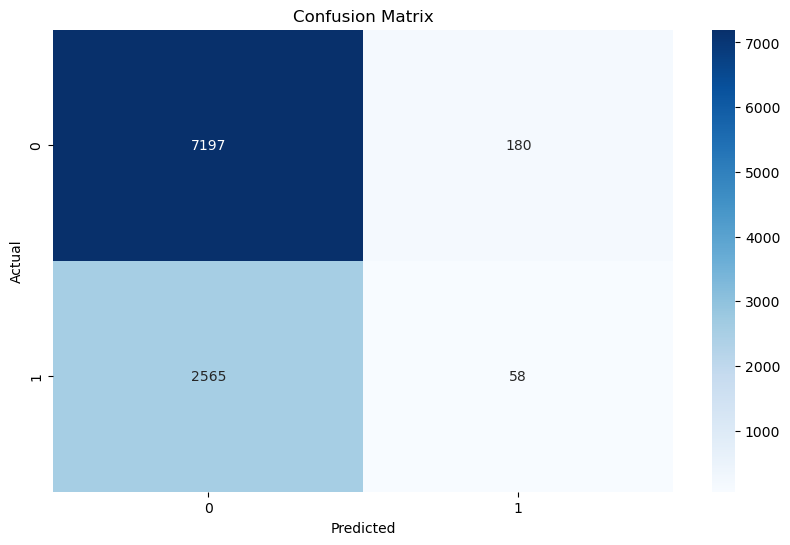

In [48]:
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


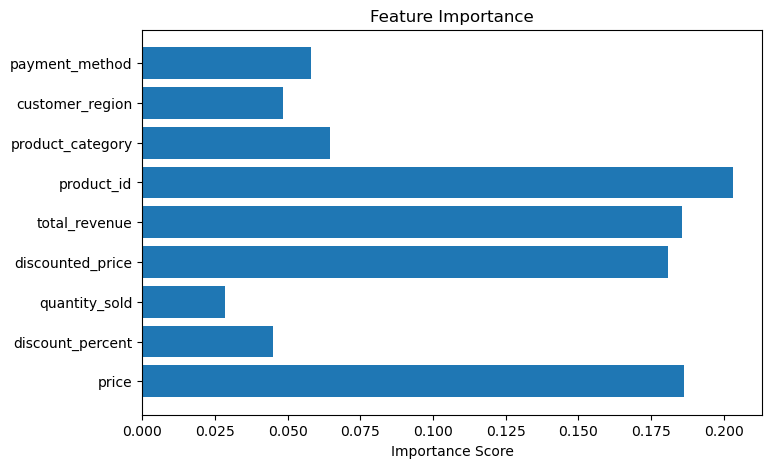

In [51]:
importances = clf.feature_importances_
features = X.columns
plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [52]:
import joblib
joblib.dump(clf, "amazon_rating_model.pkl")
print("\nClf saved successfully!")


Clf saved successfully!
